# Filtros de suavização

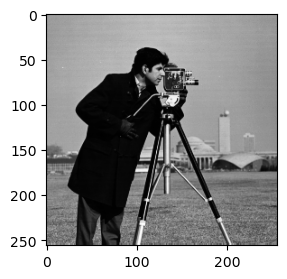

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import convolve as sp_convolve

def convolve(img, w):
    """Define uma função que passa o parâmetro mode="same" para não termos 
    que digitar ele toda vez que usarmos a convolução."""
    return sp_convolve(img, w, mode="same")


img = plt.imread("../../dados/cameraman.tiff")
plt.imshow(img, "gray")

# Filtro de média simples

In [2]:
# Cria filtro de média simples com tamanho tam
tam = 5
# Cria filtro tam x tam preenchido com o valor 1
w = np.ones([tam, tam])
# Normaliza o filtro dividindo cada elemento pelo número total de elementos (tam**2)
w = w / tam**2
print(w)

[[0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]]


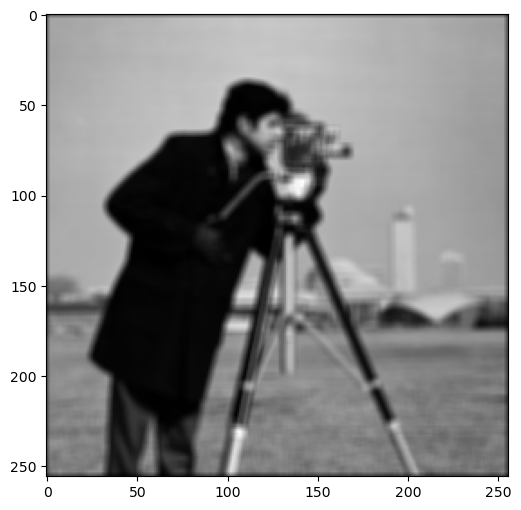

In [3]:
img_smoothed = convolve(img, w)
plt.figure(figsize=[6,6])
plt.imshow(img_smoothed, "gray")

Na imagem resultante, observe as diversas "linhas" que aparecem na imagem

# Filtro de suavização gaussiana

A função gaussiana é definida pela equação
\begin{equation}
y(x) = \frac{1}{\sigma\sqrt{2\pi}}exp\left({-\frac{(x-\mu)^2}{2\sigma^2}}\right)
\end{equation}
onde $\mu$ é o ponto central da função. Consideraremos que $\mu=0$. 

O termo $1/\sigma\sqrt{2\pi}$ garante que a soma do filtro seja 1. Não precisamos nos preocupar com ele. Basta criarmos o filtro utilizando a exponencial e dividir todos os valores pela soma.

## 1. Visualização da função gaussiana

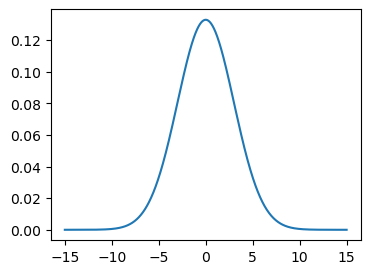

In [4]:
sigma = 3
x = np.linspace(-5*sigma, 5*sigma, 1000)
y = np.exp(-x**2/(2*sigma**2))
y = y/(sigma*np.sqrt(2*np.pi))
plt.plot(x, y)

## 2. Filtro gaussiano em uma dimensão

In [5]:
def gaussian_filter_1d(filter_size):
    sigma = filter_size/6.
    x = np.linspace(-3*sigma, 3*sigma, filter_size)
    y = np.exp(-x**2/(2*sigma**2))
    
    # Filtros de suavização precisam ter soma igual a 1
    y = y/np.sum(y)

    return y

y = gaussian_filter_1d(5)
print(y)

[0.00664603 0.19422555 0.59825683 0.19422555 0.00664603]


In [6]:
# Sinal 1D simples, representado como uma matriz de uma única linha
signal = np.array([[0, 0, 0, 0, 1, 0, 0, 0, 0]])
# O filtro gaussiano definido acima é um array 1D, como nossa função de convolução
# espera um array 2D, redimensionamos o filtro para um array 2D de uma linha
w = y.reshape(1, len(y))
filtered_signal = convolve(signal, w)
print("Sinal filtrado: ")
print(filtered_signal)

Sinal filtrado: 
[[0.         0.         0.00664603 0.19422555 0.59825683 0.19422555
  0.00664603 0.         0.        ]]


Note que o sinal filtrado possui exatamente os valores do filtro utilizado. Isso porque o sinal é um impulso (valor 1 cercado de zeros). Dessa forma, podemos interpretar a suavização da seguinte forma: o valor 1 do sinal é "espalhado" (difundido) ao longo da sua vizinhança.

Text(0.5, 1.0, 'Sinal filtrado')

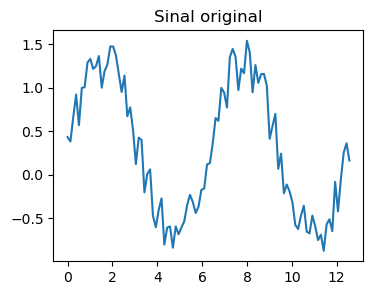

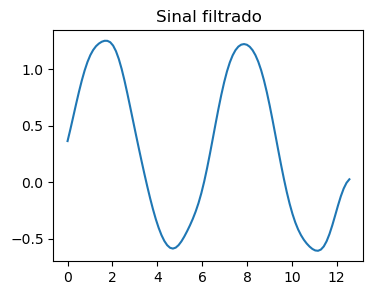

In [7]:
# Filtragem de uma função seno ruidosa
# Cria função seno com um pouco de ruído
x = np.linspace(0, 4*np.pi, 100)
corrupted_sin = np.sin(x) + 0.6*np.random.rand(len(x))
plt.plot(x, corrupted_sin)
plt.title("Sinal original")

# Filtra sinal
s = 21
w = gaussian_filter_1d(s).reshape(1, s)
corrupted_sin = corrupted_sin.reshape(1, len(corrupted_sin))
filtered_signal = convolve(corrupted_sin, w)
plt.figure()
plt.plot(x, filtered_signal[0])
plt.title("Sinal filtrado")

## 3. Filtro gaussiano bidimensional

Função gaussiana em duas dimensões:

\begin{equation}
z(x) = \frac{1}{2\pi\sigma^2}exp\left({-\frac{(x-\mu_x)^2 + (y-\mu_y)^2}{2\sigma^2}}\right)
\end{equation}
onde $\mu_x$ e $\mu_y$ indicam o ponto central da função em $x$ e $y$. Consideraremos que o centro da função é a origem ($\mu_x=0$ e $\mu_y=0$).

In [8]:
def gaussian_filter_2d(filter_size):
    sigma = filter_size/6.
    x_vals = np.linspace(-3*sigma, 3*sigma, filter_size)
    y_vals = x_vals.copy()
    z = np.zeros((filter_size, filter_size))
    for row in range(filter_size):
        x = x_vals[row]
        for col in range(filter_size):
            y = y_vals[col]
            z[row, col] = np.exp(-(x**2+y**2)/(2*sigma**2))
    z = z/np.sum(z)

    return z

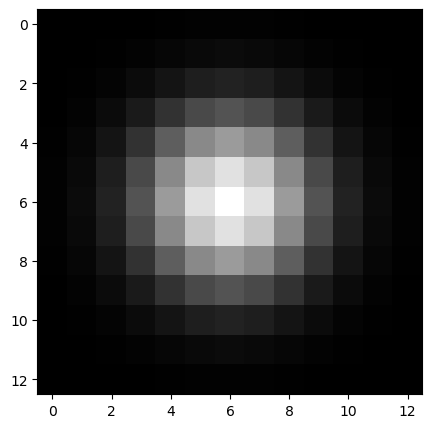

In [9]:
w = gaussian_filter_2d(13)
plt.figure(figsize=[5,5])
plt.imshow(w, "gray")

Text(0.5, 1.0, 'Imagem filtrada')

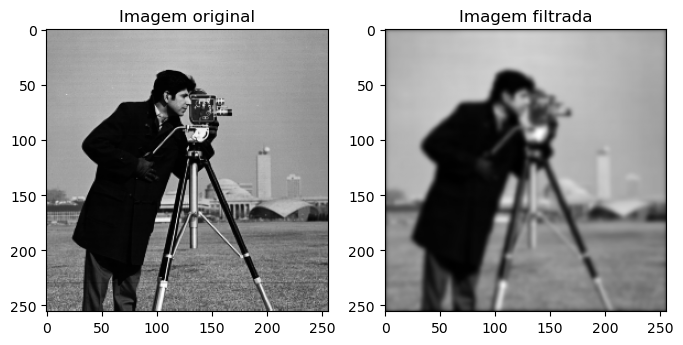

In [10]:
img = plt.imread("../../dados/cameraman.tiff")
img_filtered = convolve(img, w)

fig, ax = plt.subplots(1, 2, figsize=[8,4])
ax[0].imshow(img, "gray")
ax[0].set_title("Imagem original")
ax[1].imshow(img_filtered, "gray")
ax[1].set_title("Imagem filtrada")

## Usando suavização para segmentar um objeto

Note que a imagem abaixo está muito ruidosa, e com isso não há como tornarmos a imagem binária utilizando uma transformação de limiarização.

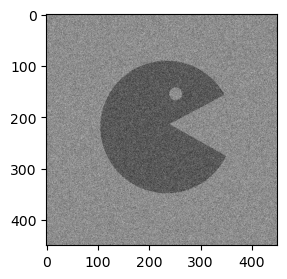

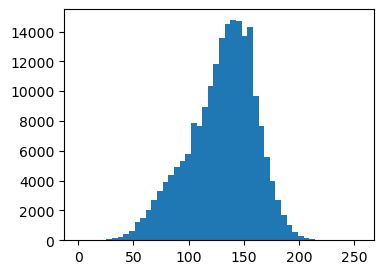

In [11]:
pacman = plt.imread("../../dados/pacman.tiff")
plt.imshow(pacman, "gray")
plt.figure()
_ = plt.hist(pacman.flatten(), 50)

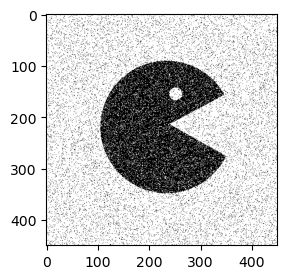

In [12]:
pacman_thresholded = pacman>110
plt.imshow(pacman_thresholded, "gray")

Ao suavizarmos a imagem, o histograma (mostrado abaixo) passa a apresentar dois picos característicos. O pico à esquerda corresponde ao objeto, enquanto que o pico à direita corresponde ao fundo da imagem. Portanto, um limiar apropriado para a imagem é um valor entre os dois picos.

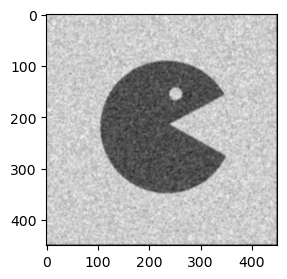

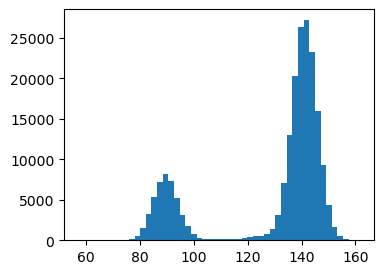

In [13]:
w = gaussian_filter_2d(9)
pacman_filtered = convolve(pacman, w)
plt.imshow(pacman_filtered, "gray")
plt.figure()
_ = plt.hist(pacman_filtered.flatten(), 50)

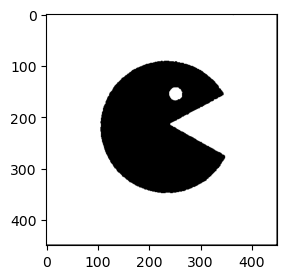

In [14]:
pacman_filt_thresholded = pacman_filtered>110
plt.imshow(pacman_filt_thresholded, "gray")